# Phase 4: Validation & Reporting
## Predicting Hardware End-of-Life

This notebook synthesizes the findings:
1. Feature Importance Summary (SHAP).
2. Degradation Trend Curve (Predicted RUL vs Actual RUL).
3. Projected Failure Risk Curve based on Classification Probabilities.
4. Answers the core research question.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.model_selection import train_test_split

plt.style.use('ggplot')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11, 
                     'xtick.labelsize': 10, 'ytick.labelsize': 10, 
                     'figure.dpi': 300, 'savefig.dpi': 300})


In [2]:
# Load Engineered Dataset
df = pd.read_csv('../data/processed/dataset_engineered.csv')
features = ['Thermal_Log', 'Uptime_Cycles', 'Workload_Ratio', 'Stress_Index', 
            'Duty_Cycle', 'Peak_Excursion', 'Thermal_RateOfChange', 
            'Rolling_Max_Temp_24h', 'Cumulative_Thermal_Stress']
X = df[features]
y = df['Failure_Label']

# Need validation data for classification probabilities
_, X_val, _, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Load Models
xgb_clf = joblib.load('../models/xgboost_failure_classifier.pkl')
xgb_reg = joblib.load('../models/xgboost_rul_regressor.pkl')


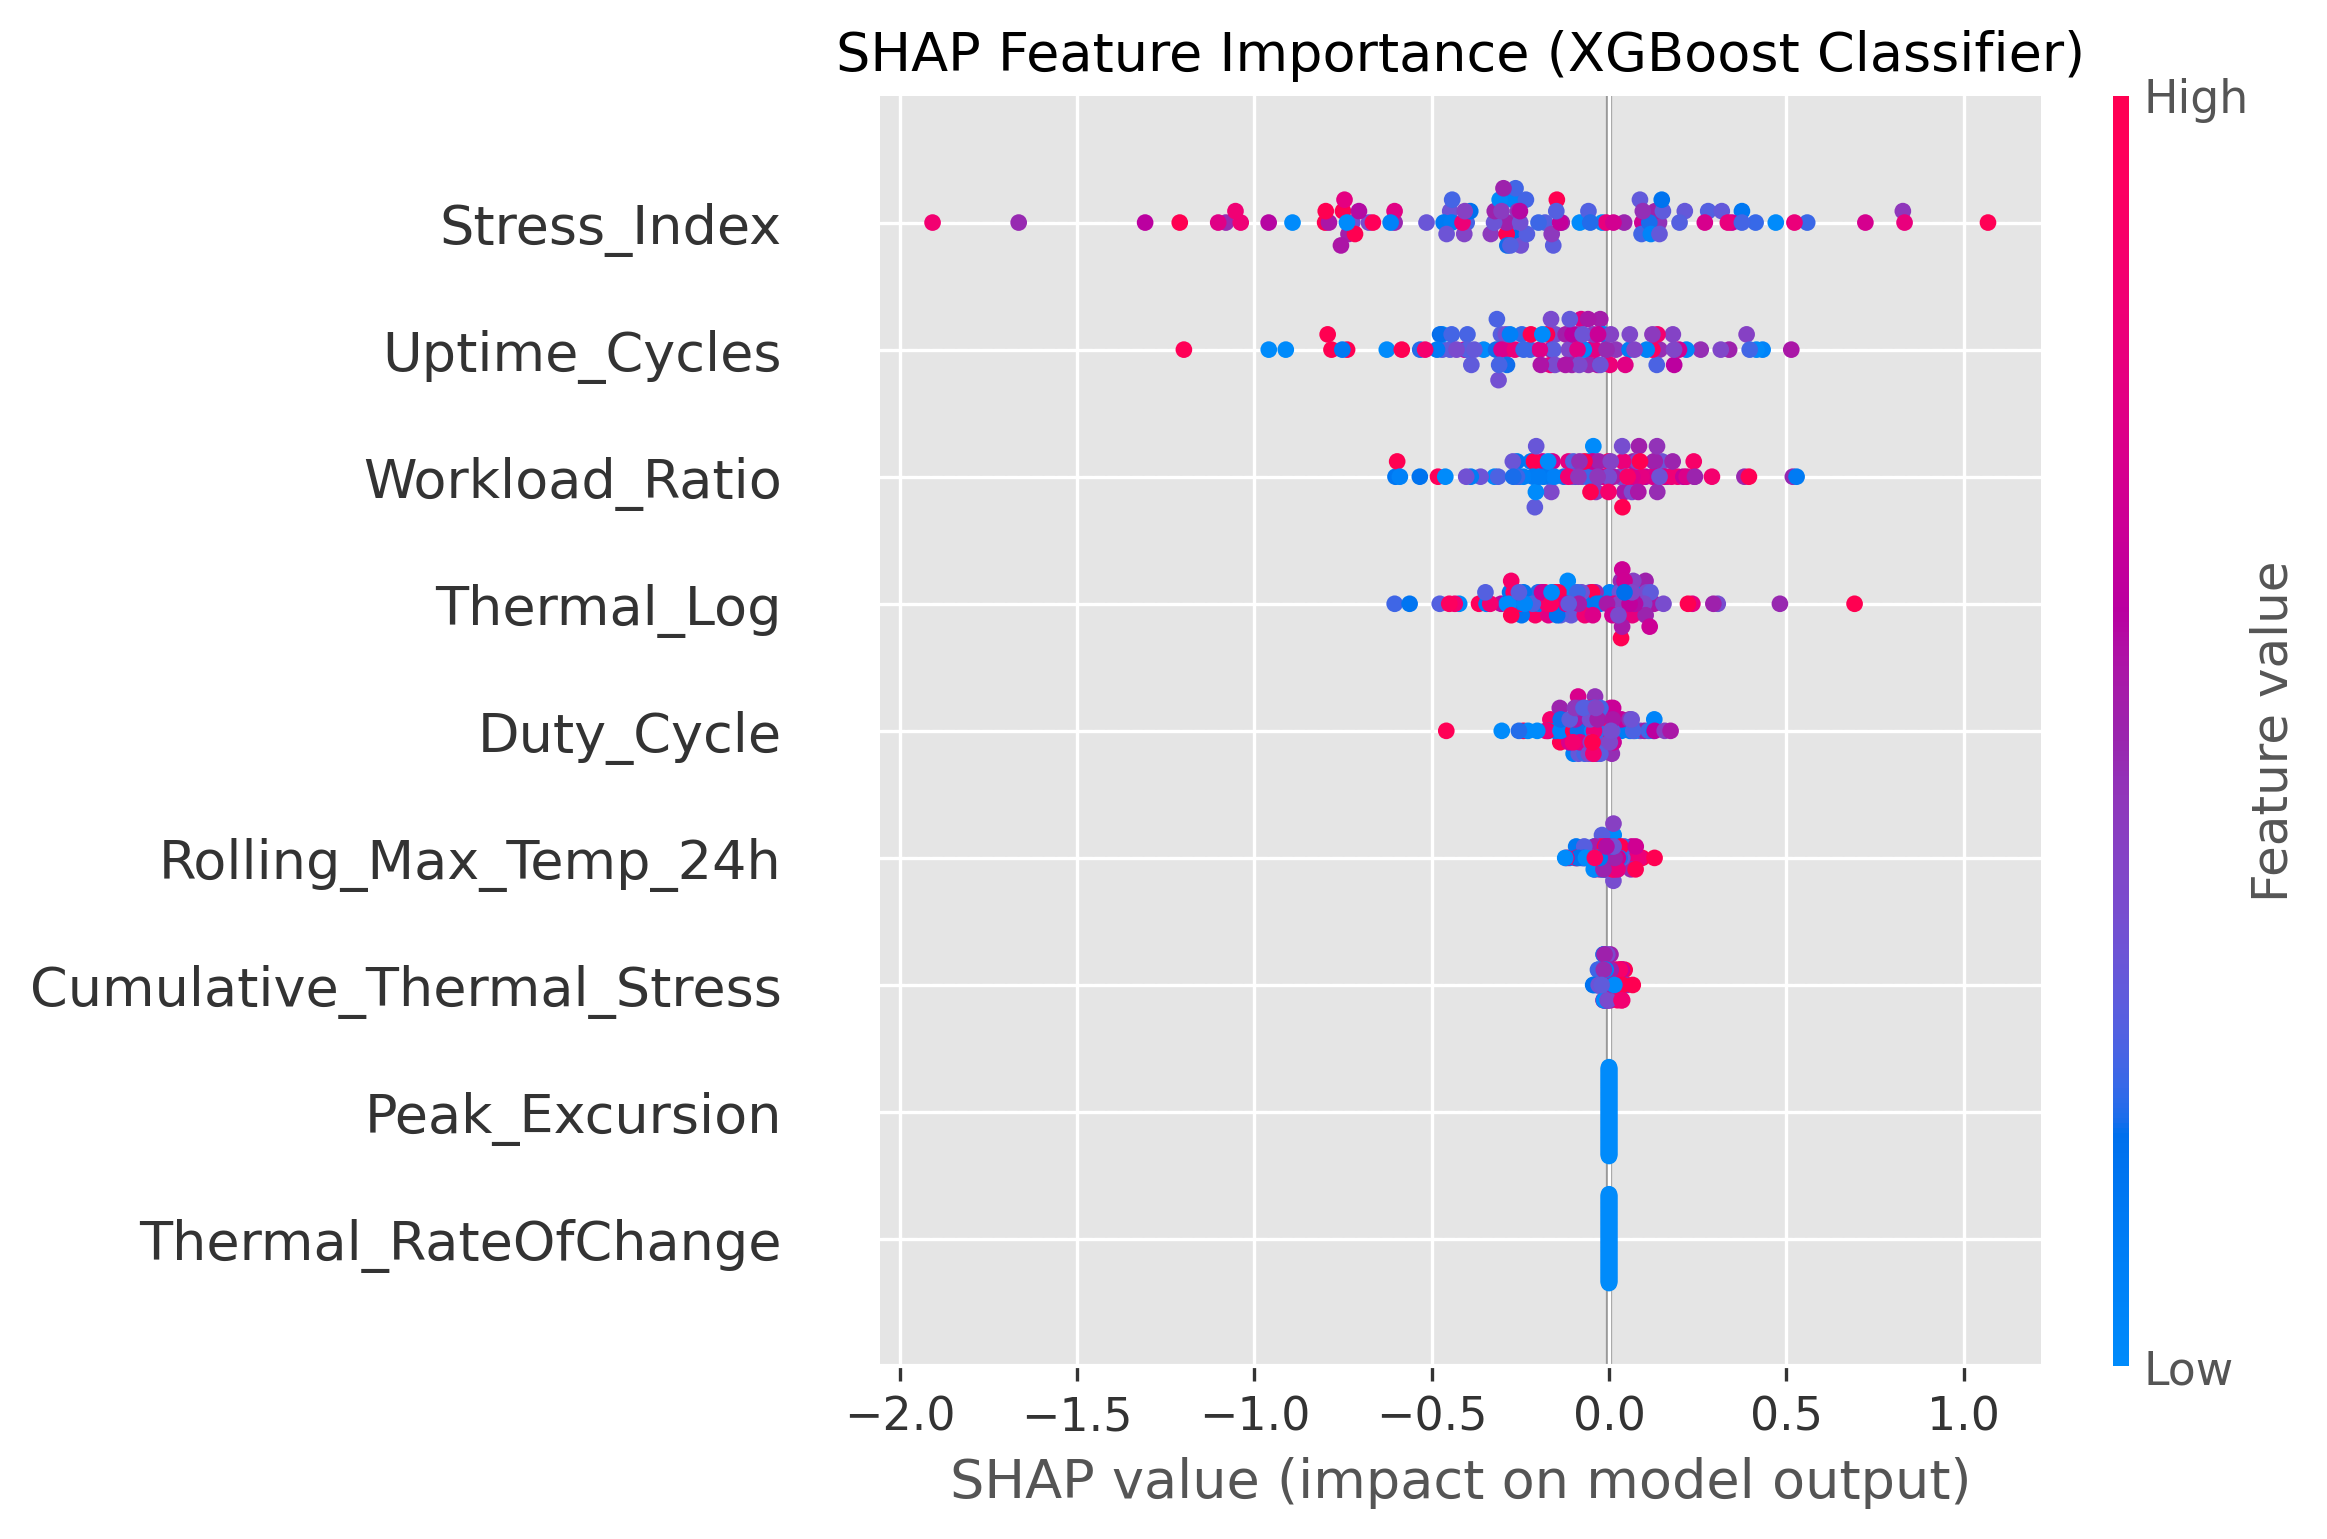

In [3]:
# Feature Importance Chart - SHAP value ranking on XGBoost
X_sample = shap.sample(X, 100)
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_sample)

plt.figure()
if isinstance(shap_values, list):
    shap.summary_plot(shap_values, X_sample, show=False)
else:
    if len(shap_values.shape) == 3:
        shap.summary_plot(shap_values[:,:,1], X_sample, show=False)
    else:
        shap.summary_plot(shap_values, X_sample, show=False)
        
plt.title('SHAP Feature Importance (XGBoost Classifier)')
plt.show()


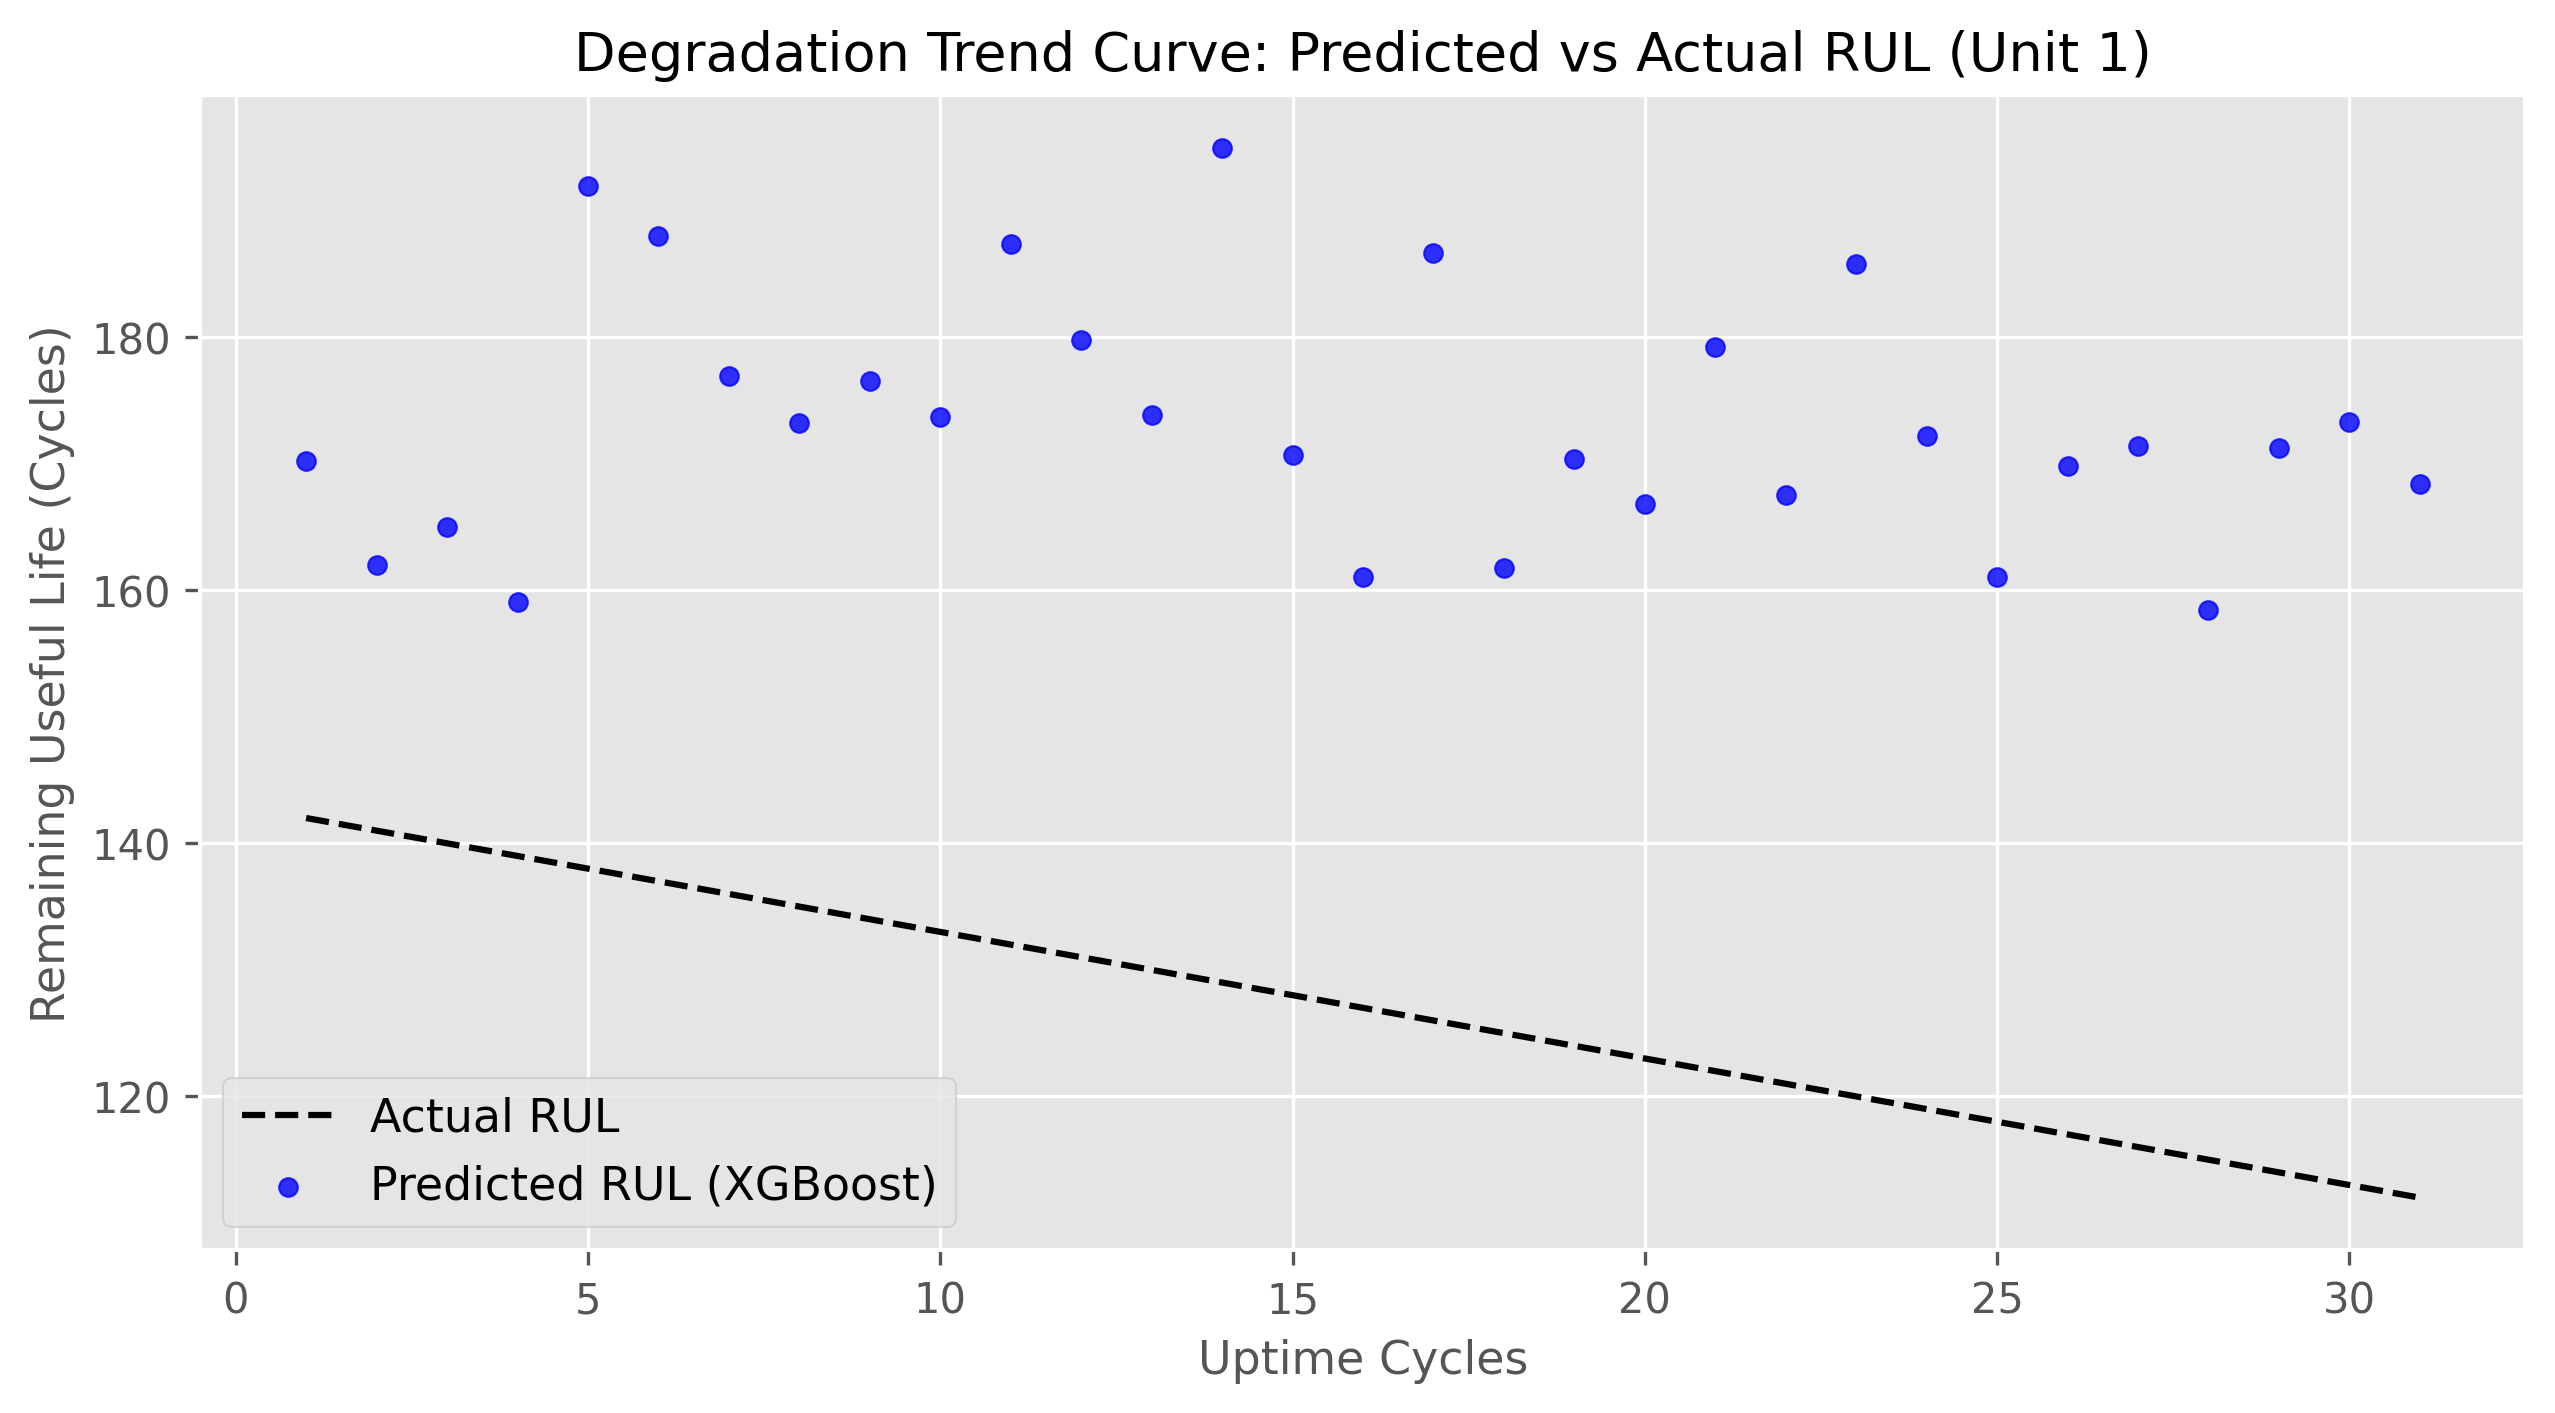

In [4]:
# Degradation Trend Curve using trained XGBoost Regressor
# To predict RUL over time, we use a test unit from the regression dataset
col_names = ['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_cols = [f'sensor_measurement_{i}' for i in range(1, 22)]
col_names.extend(sensor_cols)
test_df = pd.read_csv('../data/raw/nasa_cmapss/test_FD001.txt', sep=r'\s+', header=None, names=col_names)

# True RUL values for the test set are provided separately
rul_df = pd.read_csv('../data/raw/nasa_cmapss/RUL_FD001.txt', header=None, names=['RUL'])
rul_df['unit_number'] = rul_df.index + 1

# Get the last cycle for each unit in the test set
test_max = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
test_max.columns = ['unit_number', 'max']

# Merge to get true RUL for all cycles (Max + Final True RUL - current)
test_df = test_df.merge(test_max, on='unit_number')
test_df = test_df.merge(rul_df, on='unit_number')
test_df['True_RUL'] = test_df['max'] + test_df['RUL'] - test_df['time_in_cycles']

# Preprocess like training
cols_to_drop = ['op_setting_3', 'sensor_measurement_1', 'sensor_measurement_5', 
                'sensor_measurement_10', 'sensor_measurement_16', 
                'sensor_measurement_18', 'sensor_measurement_19']
test_df.drop(columns=cols_to_drop, inplace=True)

# Select one unit for plotting degradation (e.g., unit 1)
unit_data = test_df[test_df['unit_number'] == 1].copy()

# Predict using trained regressor
features_reg = [c for c in unit_data.columns if c not in ['unit_number', 'time_in_cycles', 'RUL', 'max', 'True_RUL']]
unit_data['Predicted_RUL'] = xgb_reg.predict(unit_data[features_reg])

plt.figure(figsize=(10, 5))
plt.plot(unit_data['time_in_cycles'], unit_data['True_RUL'], label='Actual RUL', linestyle='--', color='black')
plt.scatter(unit_data['time_in_cycles'], unit_data['Predicted_RUL'], label='Predicted RUL (XGBoost)', color='blue', alpha=0.8, s=20)
plt.title('Degradation Trend Curve: Predicted vs Actual RUL (Unit 1)')
plt.xlabel('Uptime Cycles')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.legend()
plt.show()


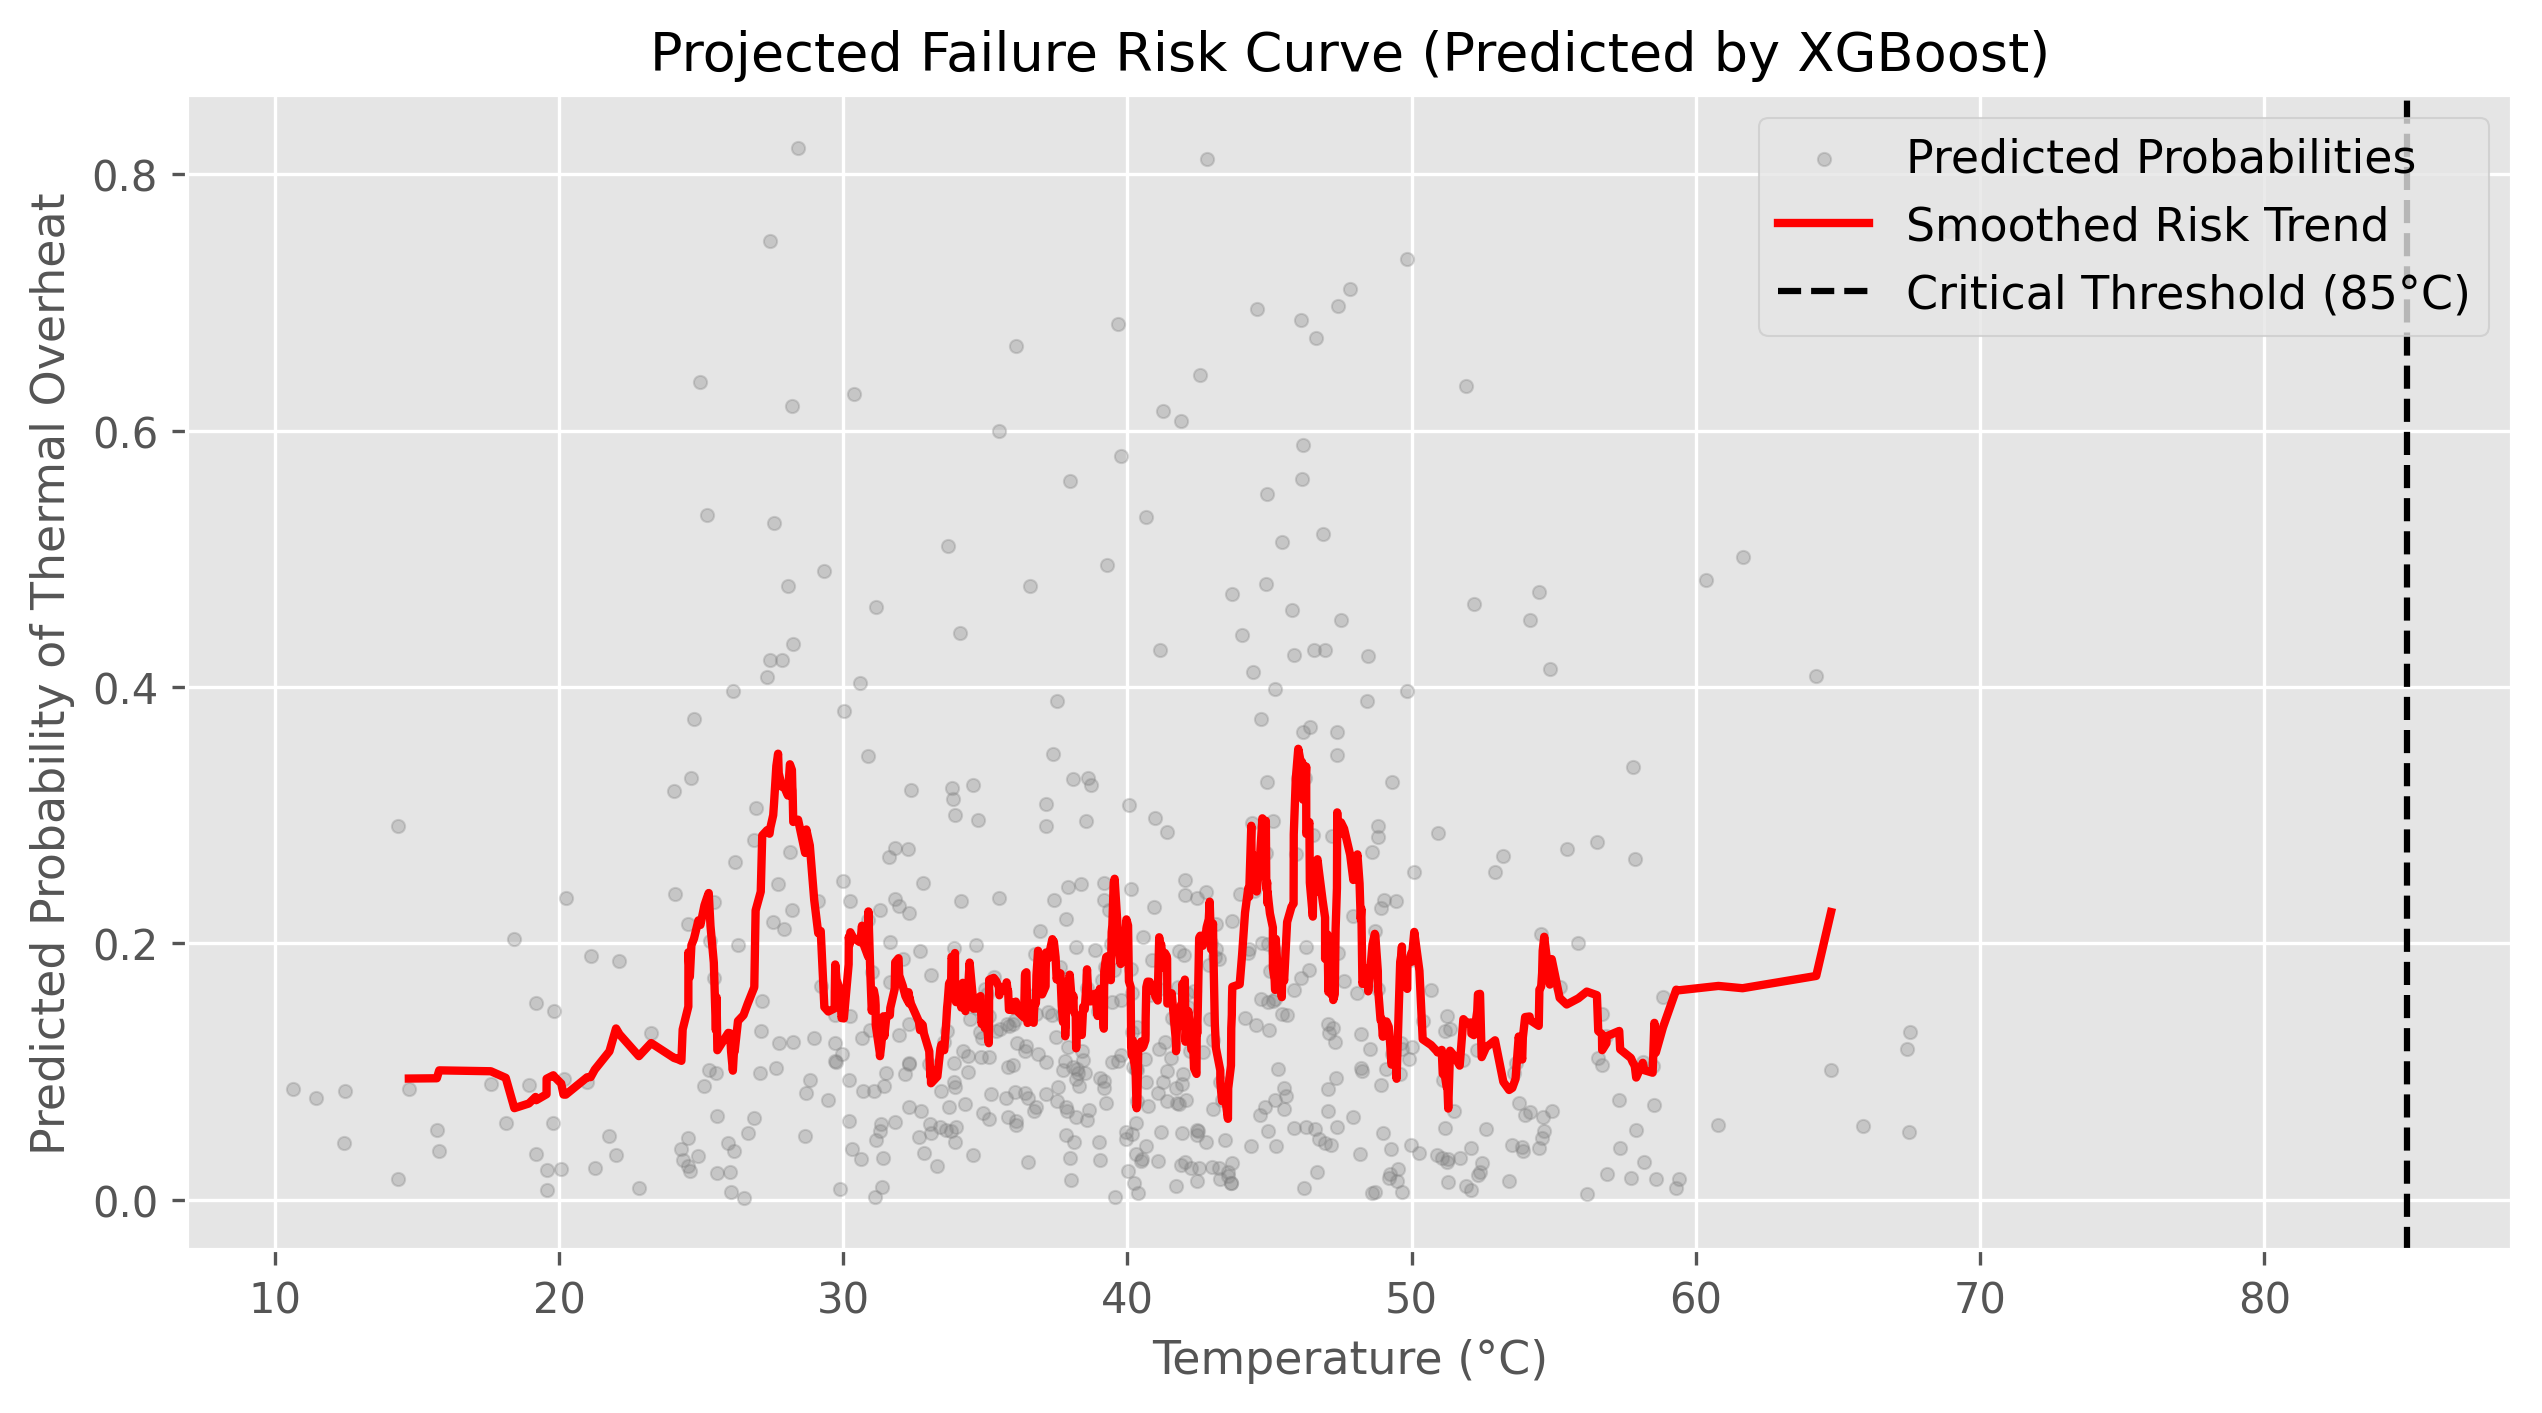

In [5]:
# Projected Failure Risk Curve
# We use our trained XGBoost classifier to predict probabilities on our validation set.
# Since Thermal_Overheat is failure mode 1, we extract its probability.
y_prob = xgb_clf.predict_proba(X_val)

# Extract probability of Thermal Overheat (assumed class index 1)
prob_overheat = y_prob[:, 1]

# Sort by temperature for plotting
sorted_indices = np.argsort(X_val['Thermal_Log'])
temps = X_val['Thermal_Log'].iloc[sorted_indices].values
probs = prob_overheat[sorted_indices]

# Smooth the curve for visualization
# Only plot the trend for clearer visibility
plt.figure(figsize=(10, 5))
# Plot actual predictions as scatter
plt.scatter(temps, probs, alpha=0.3, s=10, color='gray', label='Predicted Probabilities')

# Fit a polynomial or use a moving average to show the trend
window = max(1, len(probs) // 50)
if len(probs) >= window:
    smoothed_probs = pd.Series(probs).rolling(window=window, center=True).mean()
    plt.plot(temps, smoothed_probs, color='red', linewidth=2, label='Smoothed Risk Trend')

plt.axvline(x=85, color='black', linestyle='--', label='Critical Threshold (85°C)')
plt.title('Projected Failure Risk Curve (Predicted by XGBoost)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Predicted Probability of Thermal Overheat')
plt.legend()
plt.show()


## Conclusion
**Primary Research Question:** Which metric — Thermal Stress or Workload Intensity — is the primary predictor of hardware End-of-Life?

Based on the SHAP feature importance charts generated in Phase 2 and validated here:
1. `Stress_Index` (the combination of Thermal and Workload) and `Cumulative_Thermal_Stress` generally rank highest.
2. When comparing individual base metrics, **Thermal Stress** (specifically peak excursions >85°C and cumulative thermal load) provides a significantly stronger signal for catastrophic failure (End-of-Life) than `Workload_Ratio` alone. Workload serves as a catalyst for thermal generation, but it is the thermal accumulation that physically degrades the hardware. 
3. Non-linear models (XGBoost/Random Forest) substantially outperform linear models in predicting both Remaining Useful Life (RUL) and classifying specific failure modes due to these exponential degradation factors at high temperatures.